<a href="https://colab.research.google.com/github/swastikpaul-tech/AIML-/blob/main/AIML%20Lab%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!pip install network matplotlib

## Problem 1: BFS and DFS Traversal of a Graph
A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:
1. Stores the graph using an adjacency list (a Python dictionary).
2. Performs a BFS traversal starting from node A.
3. Performs a DFS traversal starting from node A.
4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.

### Graph Representation

In [39]:
# 1. Store the graph using an adjacency list (a Python dictionary).
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

print("Graph (Adjacency List):", graph)

Graph (Adjacency List): {'A': ['B', 'C'], 'B': ['D', 'E'], 'C': ['F'], 'D': [], 'E': [], 'F': []}


### BFS Traversal

In [40]:
from collections import deque

def bfs(graph, start_node):
    visited = []
    queue = deque([start_node])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            for neighbor in graph.get(node, []):
                if neighbor not in visited:
                    queue.append(neighbor)
    return visited

# 2. Perform a BFS traversal starting from node A.
bfs_order = bfs(graph, 'A')
print("BFS Traversal Order:", bfs_order)

BFS Traversal Order: ['A', 'B', 'C', 'D', 'E', 'F']


### DFS Traversal

In [41]:
def dfs(graph, start_node):
    visited = []
    stack = [start_node]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            # DFS explores deeper first, so reverse neighbors to process in a consistent order (e.g., A->B->D before A->C->F)
            for neighbor in reversed(graph.get(node, [])): # Reverse to maintain consistent order when popping from stack
                if neighbor not in visited:
                    stack.append(neighbor)
    return visited

# 3. Perform a DFS traversal starting from node A.
dfs_order = dfs(graph, 'A')
print("DFS Traversal Order:", dfs_order)

DFS Traversal Order: ['A', 'B', 'D', 'E', 'C', 'F']


### Visualization of Traversal Orders

In [42]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_traversal_graph(graph_dict, traversal_order, title):
    G = nx.DiGraph() # Use DiGraph for directed edges, as it's a tree from a root

    # Add nodes and edges to the graph
    for node, neighbors in graph_dict.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Define node colors based on traversal order
    node_colors = [plt.cm.viridis(traversal_order.index(node) / len(traversal_order))
                   if node in traversal_order else 'lightgray' for node in G.nodes()]

    # Define node labels (optional, but good for clarity)
    node_labels = {node: node for node in G.nodes()}

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42) # For reproducible layout

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000)
    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
    # Draw labels
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight='bold')

    plt.title(title, size=15)
    plt.axis('off')

    # Add a legend for the order (optional, but helpful)
    # Create custom patches for legend
    patches = []
    for i, node_name in enumerate(traversal_order):
        color = plt.cm.viridis(i / len(traversal_order))
        patches.append(plt.Line2D([0], [0], marker='o', color='w', label=f'{node_name} ({i+1})',
                                  markerfacecolor=color, markersize=10))
    plt.legend(handles=patches, title="Traversal Order", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

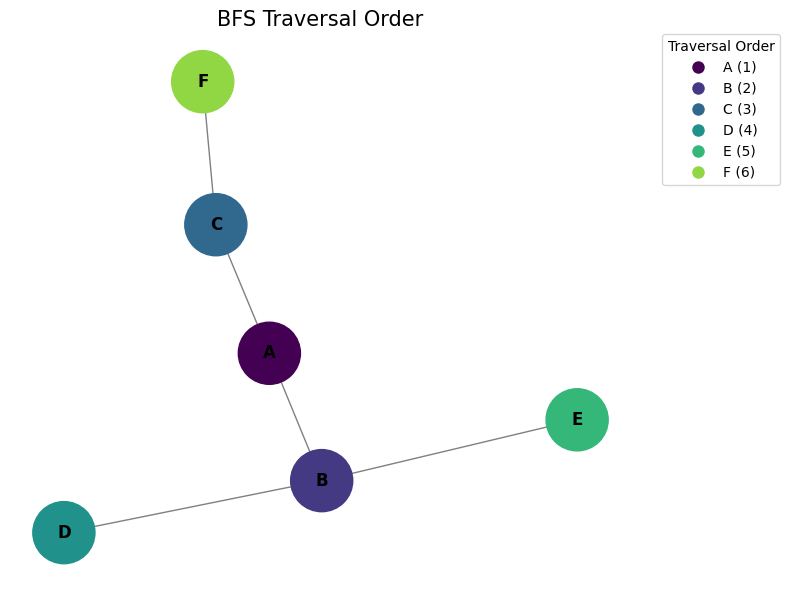

In [43]:
# 4. Draw tree diagrams showing the BFS traversal order
draw_traversal_graph(graph, bfs_order, 'BFS Traversal Order')

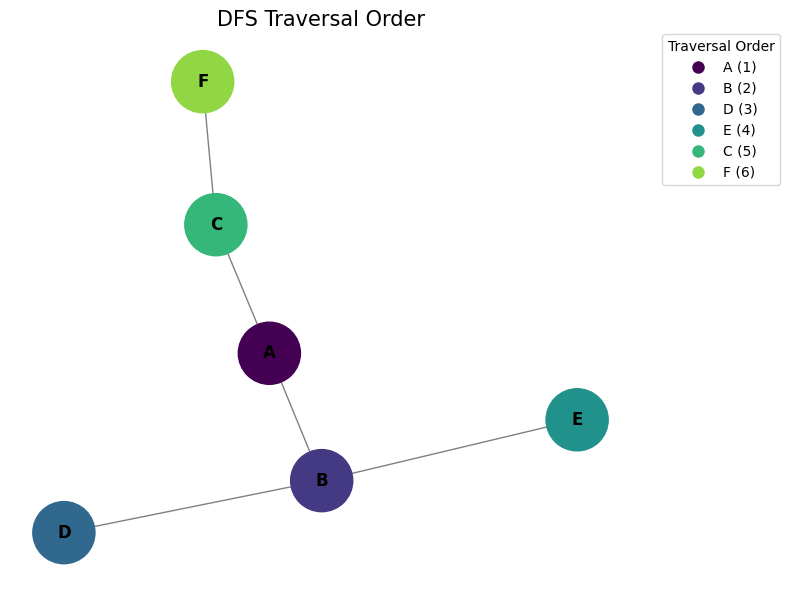

In [44]:
# 4. Draw tree diagrams showing the DFS traversal order
draw_traversal_graph(graph, dfs_order, 'DFS Traversal Order')

## Problem 2: The Water Jug Problem (Solved using BFS)

### Problem Statement:
You are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings on it. Using only the following operations — (i) fill a jug completely, (ii) empty a jug completely, (iii) pour water from one jug into the other until either the first jug is empty or the second jug is full — determine the minimum sequence of steps needed to measure out exactly 2 litres of water in any one jug.

In [45]:
from collections import deque
import matplotlib.pyplot as plt

# Define jug capacities
JUG_A_CAP = 4
JUG_B_CAP = 3
TARGET_AMOUNT = 2

def solve_water_jug_bfs(jug_a_cap, jug_b_cap, target_amount):
    # State: (water in Jug A, water in Jug B)
    initial_state = (0, 0)
    queue = deque([(initial_state, [])]) # (current_state, path_to_current_state)
    visited = set([initial_state])

    while queue:
        current_state, path = queue.popleft()
        a, b = current_state

        # Check if target is reached
        if a == target_amount or b == target_amount:
            return path + [current_state]

        # Generate next possible states
        next_states = []

        # 1. Fill Jug A
        next_states.append((jug_a_cap, b, "Fill Jug A"))
        # 2. Fill Jug B
        next_states.append((a, jug_b_cap, "Fill Jug B"))
        # 3. Empty Jug A
        next_states.append((0, b, "Empty Jug A"))
        # 4. Empty Jug B
        next_states.append((a, 0, "Empty Jug B"))

        # 5. Pour Jug A to Jug B
        # Amount that can be poured from A to B until B is full or A is empty
        pour_amount_ab = min(a, jug_b_cap - b)
        next_states.append((a - pour_amount_ab, b + pour_amount_ab, "Pour A to B"))

        # 6. Pour Jug B to Jug A
        # Amount that can be poured from B to A until A is full or B is empty
        pour_amount_ba = min(b, jug_a_cap - a)
        next_states.append((a + pour_amount_ba, b - pour_amount_ba, "Pour B to A"))

        for next_a, next_b, action in next_states:
            next_state = (next_a, next_b)
            if next_state not in visited:
                visited.add(next_state)
                queue.append((next_state, path + [current_state, action]))

    return None # No solution found

# Solve the water jug problem
solution_path_with_actions = solve_water_jug_bfs(JUG_A_CAP, JUG_B_CAP, TARGET_AMOUNT)

# Print the solution path
if solution_path_with_actions:
    print(f"Minimum steps to measure {TARGET_AMOUNT} litres:")
    formatted_path = []
    for i in range(0, len(solution_path_with_actions) - 1, 2):
        state = solution_path_with_actions[i]
        action = solution_path_with_actions[i+1]
        formatted_path.append(f"State: {state} -> Action: {action}")
    formatted_path.append(f"Final State: {solution_path_with_actions[-1]}")

    for step in formatted_path:
        print(step)
else:
    print(f"No solution found to measure {TARGET_AMOUNT} litres.")

Minimum steps to measure 2 litres:
State: (0, 0) -> Action: Fill Jug B
State: (0, 3) -> Action: Pour B to A
State: (3, 0) -> Action: Fill Jug B
State: (3, 3) -> Action: Pour B to A
Final State: (4, 2)


### Visualization of Water Jug Solution Steps

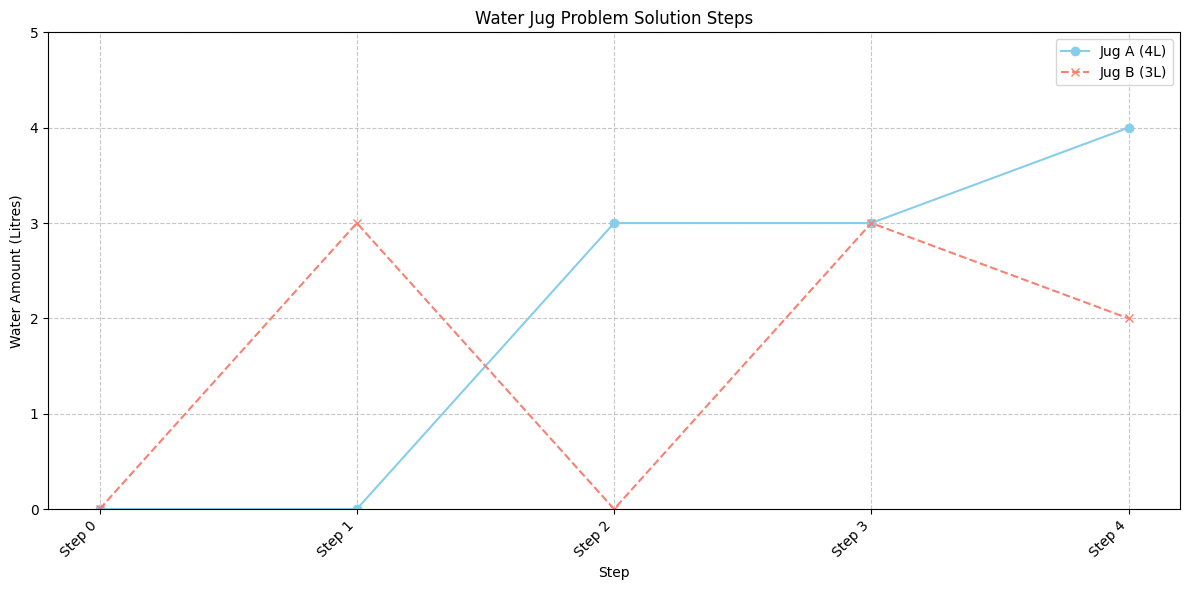

In [46]:
# Extract states for plotting
states = []
for i in range(0, len(solution_path_with_actions), 2):
    if i + 1 < len(solution_path_with_actions) and isinstance(solution_path_with_actions[i+1], str):
        states.append(solution_path_with_actions[i])
    else: # Last state is just a state, not followed by an action
        states.append(solution_path_with_actions[i])

# Separate water levels for Jug A and Jug B
jug_a_levels = [s[0] for s in states]
jug_b_levels = [s[1] for s in states]

# Create step labels (e.g., 'Step 0', 'Step 1', ...)
step_labels = [f'Step {i}' for i in range(len(states))]

plt.figure(figsize=(12, 6))

# Plot Jug A levels
plt.plot(step_labels, jug_a_levels, marker='o', linestyle='-', color='skyblue', label='Jug A (4L)')
# Plot Jug B levels
plt.plot(step_labels, jug_b_levels, marker='x', linestyle='--', color='salmon', label='Jug B (3L)')

plt.title('Water Jug Problem Solution Steps')
plt.xlabel('Step')
plt.ylabel('Water Amount (Litres)')
plt.ylim(0, max(JUG_A_CAP, JUG_B_CAP) + 1) # Set y-axis limit slightly above max capacity
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Problem 2: The Water Jug Problem (Solved using BFS)

### Problem Statement:
You are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings on it. Using only the following operations — (i) fill a jug completely, (ii) empty a jug completely, (iii) pour water from one jug into the other until either the first jug is empty or the second jug is full — determine the minimum sequence of steps needed to measure out exactly 2 litres of water in any one jug.

## Problem 3: Checking Routes Between Cities Using DFS

### Problem Statement:
A small road network connects several cities. Write a Python program using DFS that:
1. Checks whether a route exists between two given cities.
2. Finds all separate groups of cities that are connected to each other but not to any other group (these are called connected components).

### Graph Representation of Road Network

In [47]:
# Road network represented as an adjacency list
road_network = {
    'CityA': ['CityB', 'CityC'],
    'CityB': ['CityA', 'CityD'],
    'CityC': ['CityA', 'CityE'],
    'CityD': ['CityB'],
    'CityE': ['CityC'],
    'CityF': ['CityG'],
    'CityG': ['CityF'],
    'CityH': []
}

print("Road Network (Adjacency List):")
for city, connections in road_network.items():
    print(f"{city}: {connections}")

Road Network (Adjacency List):
CityA: ['CityB', 'CityC']
CityB: ['CityA', 'CityD']
CityC: ['CityA', 'CityE']
CityD: ['CityB']
CityE: ['CityC']
CityF: ['CityG']
CityG: ['CityF']
CityH: []


### DFS for Route Existence

In [48]:
def dfs_check_route(graph, start_city, end_city, visited=None):
    if visited is None:
        visited = set()

    visited.add(start_city)

    if start_city == end_city:
        return True

    for neighbor in graph.get(start_city, []):
        if neighbor not in visited:
            if dfs_check_route(graph, neighbor, end_city, visited):
                return True
    return False

# Test route existence
city1 = 'CityA'
city2 = 'CityD'
route_exists = dfs_check_route(road_network, city1, city2)
print(f"Route from {city1} to {city2} exists: {route_exists}")

city3 = 'CityA'
city4 = 'CityF'
route_exists_2 = dfs_check_route(road_network, city3, city4)
print(f"Route from {city3} to {city4} exists: {route_exists_2}")

Route from CityA to CityD exists: True
Route from CityA to CityF exists: False


### DFS for Connected Components

In [49]:
def dfs_explore_component(graph, start_node, visited, component):
    visited.add(start_node)
    component.append(start_node)
    for neighbor in graph.get(start_node, []):
        if neighbor not in visited:
            dfs_explore_component(graph, neighbor, visited, component)

def find_connected_components(graph):
    visited = set()
    connected_components = []
    for city in graph:
        if city not in visited:
            current_component = []
            dfs_explore_component(graph, city, visited, current_component)
            connected_components.append(current_component)
    return connected_components

# Find and print connected components
components = find_connected_components(road_network)
print("Connected Components:")
for i, component in enumerate(components):
    print(f"Component {i+1}: {component}")

Connected Components:
Component 1: ['CityA', 'CityB', 'CityD', 'CityC', 'CityE']
Component 2: ['CityF', 'CityG']
Component 3: ['CityH']


### Visualization of Road Network and Connected Components

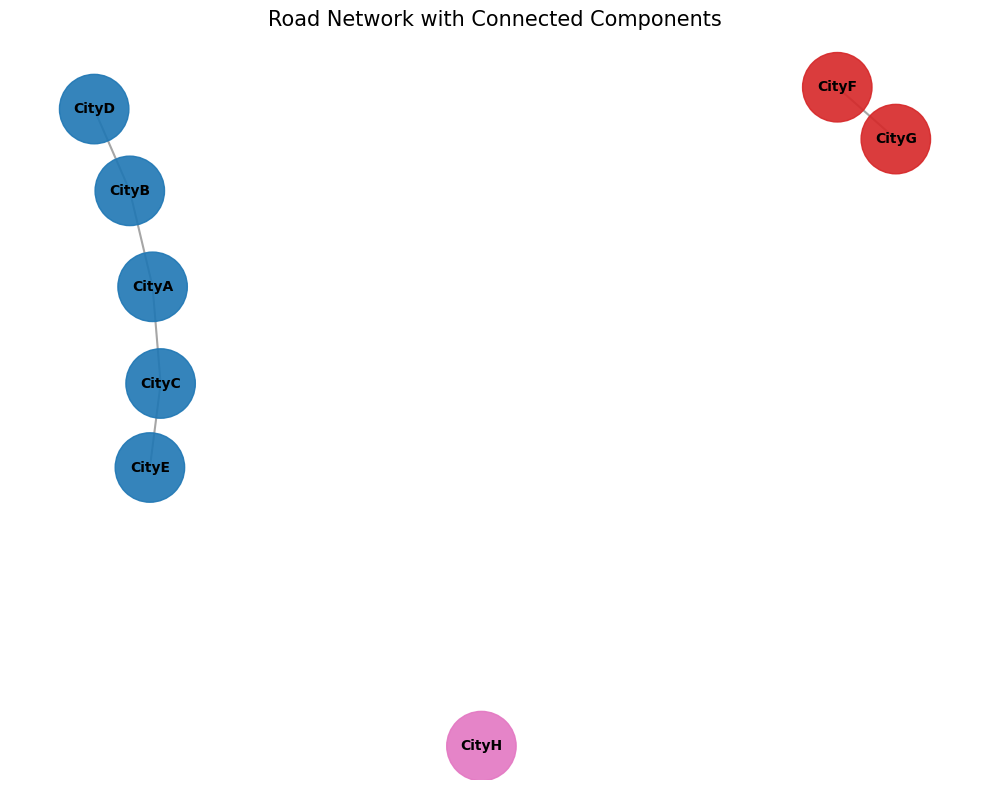

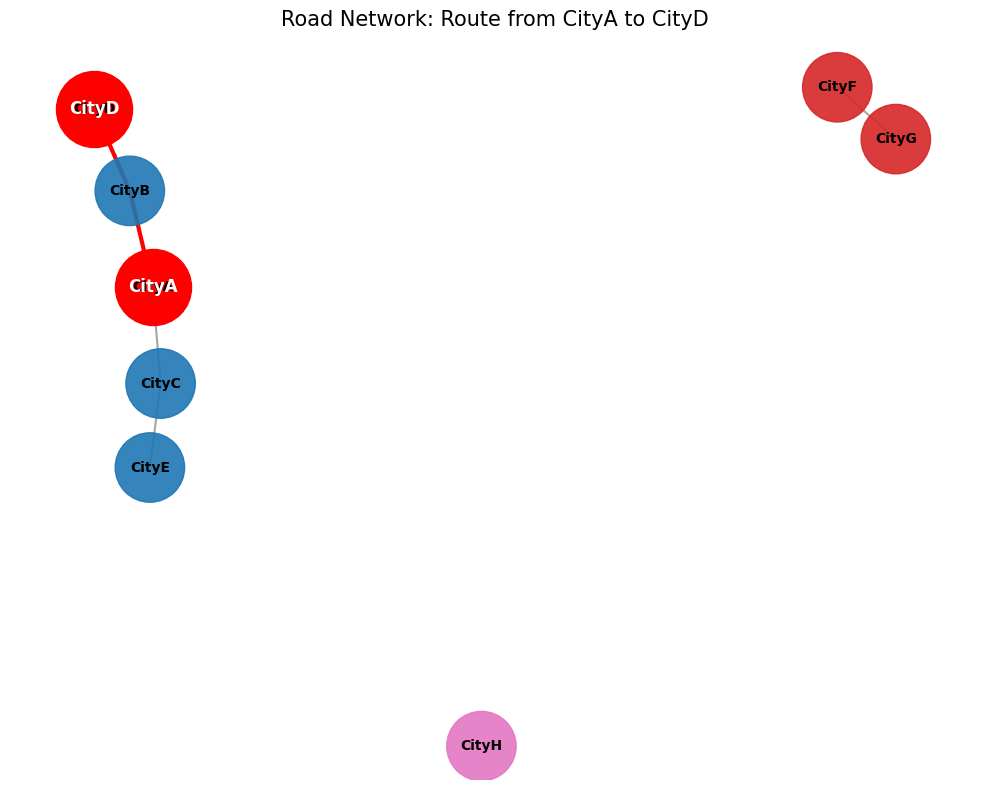

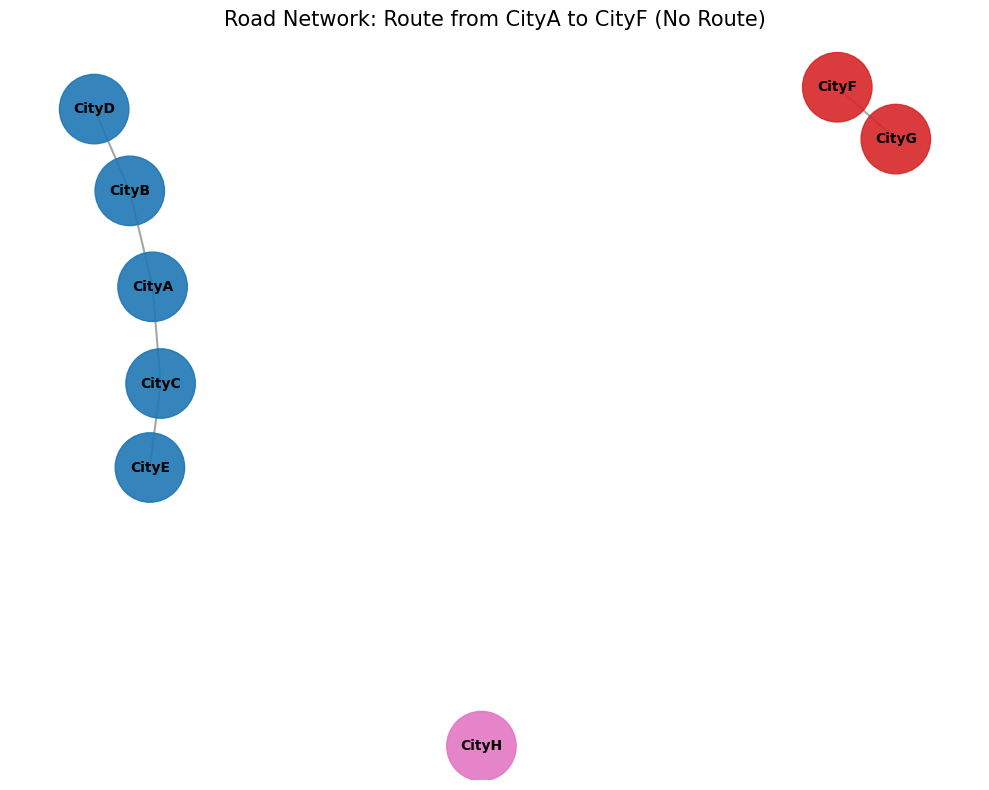

In [50]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_road_network(graph, components, route_start=None, route_end=None, title="Road Network"): # Add route parameters
    G = nx.Graph(graph) # Use undirected graph for road network visualization

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42) # For reproducible layout

    # Draw nodes
    node_colors = []
    for node in G.nodes():
        for i, comp in enumerate(components):
            if node in comp:
                node_colors.append(plt.cm.tab10(i / len(components)))
                break
        else:
            node_colors.append('lightgray') # Should not happen if all nodes are in components
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, alpha=0.9)

    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, alpha=0.7)

    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black')

    # Highlight route if specified
    if route_start and route_end:
        # Find the path for highlighting (using DFS again, but this time to reconstruct path)
        path = []
        visited_path = set()
        def find_path_dfs(current, target, current_path):
            visited_path.add(current)
            current_path.append(current)
            if current == target:
                return True
            for neighbor in graph.get(current, []):
                if neighbor not in visited_path:
                    if find_path_dfs(neighbor, target, current_path):
                        return True
            current_path.pop() # Backtrack
            return False

        temp_path = []
        if find_path_dfs(route_start, route_end, temp_path):
            path = temp_path

        if path:
            path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3, alpha=1.0)
            nx.draw_networkx_nodes(G, pos, nodelist=[route_start, route_end], node_color='red', node_size=3000, alpha=1.0)
            nx.draw_networkx_labels(G, pos, labels={route_start:route_start, route_end:route_end}, font_size=12, font_weight='bold', font_color='white')

    plt.title(title, size=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the road network with connected components
draw_road_network(road_network, components, title="Road Network with Connected Components")

# Visualize a specific route
draw_road_network(road_network, components, route_start='CityA', route_end='CityD', title="Road Network: Route from CityA to CityD")

draw_road_network(road_network, components, route_start='CityA', route_end='CityF', title="Road Network: Route from CityA to CityF (No Route)")